# 6. The Bell Experiment: Surprising Consequences of Entanglement

In 1964, physicist John Stewart Bell proposed a thought experiment that would forever change our understanding of reality$^{[1]}$. He asked a fundamental question: **Is the universe locally real?**

* **Realism:** Do objects have definite properties (like position or spin) even when we are not looking at them?
* **Locality:** Can objects influence each other instantaneously across vast distances?

Einstein, Podolsky, and Rosen (EPR) argued that quantum mechanics was "incomplete" because entanglement seemed to violate locality ("spooky action at a distance"). They suggested that there must be "Hidden Variables"—secret, pre-determined instructions inside the particles—that determine measurement outcomes, preserving local realism.

Bell derived a mathematical inequality (the **Bell Inequality** or **CHSH Inequality**) that any theory based on local hidden variables *must* obey.
$$
|S| \leq 2
$$
However, quantum mechanics predicts that for entangled pairs measured in specific bases, this value can reach $2\sqrt{2} \approx 2.82$.

Below is an illustration of the experimental setup. The Polarizing Beam splitters are turnable after the creation of the entangled pair. This closes the loop-hole that the photons would "know" before-hand how they would be measured, proving that this correlation is a true quantum effect.

<img src="images/Bell-Tests.png" width="900">

In this notebook, you will simulate a Bell test. You will create entangled pairs, rotate them into specific measurement bases, and calculate the correlation value $S$. If $S > 2$, you have mathematically proven that nature cannot be described by local hidden variables.

## 6.1. The CHSH Game

To test the inequality, Alice and Bob measure their qubits in two different bases each:
* **Alice** chooses between basis $A$ and $a$.
* **Bob** chooses between basis $B$ and $b$.

They calculate the expectation value (correlation) $E$ for each combination of bases. The CHSH correlation parameter $S$ is defined as:

$$
S = E(A, B) + E(A, b) + E(a, B) - E(a, b)
$$

If classical physics (local realism) holds, $|S| \leq 2$.
If quantum mechanics holds, we can find bases where $S > 2$.

### The Winning Strategy
To violate the inequality, we use the correlated Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ and the following measurement angles:
* Alice A: $0$ (Z-basis)
* Alice a: $\pi/2$ (X-basis)
* Bob B: $\pi/4$
* Bob b: $-\pi/4$

<details style="background-color: #4c3575; color: #ffffff; border: 1px solid #ccc; padding: 10px; border-radius: 5px;">
<summary style="cursor: pointer; color: #ffffff;"><strong>(Optional) Mathematical Derivation: Expectation Values via the Born Rule</strong></summary>

<div style="background-color: #4c3575; color: #ffffff; padding: 10px; margin-top: 10px; border-left: 3px solid #0066cc;">
  <h3>Derivation of Expectation Values via the Born Rule</h3>
  <p>To understand the specific numerical values in the Bell inequality violation (e.g., $\frac{2+\sqrt{2}}{8}$ or $\frac{1}{\sqrt{2}}$), we must apply the Born rule to the quantum state after basis rotation.</p>

  <h4>1. The Initial State</h4>
  <p>We begin with the Bell state $|\Phi^+\rangle$, which describes the entanglement between Qubit #1 (Alice) and Qubit #2 (Bob):</p>
  <p>$$|\psi_{init}\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle)$$</p>

  <h4>2. The Measurement Bases</h4>
  <p>In the experiment, Alice and Bob choose specific measurement bases. A measurement in an arbitrary basis can be modeled as applying a unitary rotation $U$ followed by a standard computational basis measurement ($Z$-basis).</p>
  <ul>
    <li><strong>Alice ($a$):</strong> Measures in $\sigma_z$. No rotation is applied ($U_A = I$).</li>
    <li><strong>Bob ($b$):</strong> Measures in $\frac{1}{\sqrt{2}}(\sigma_x + \sigma_z)$. This corresponds to applying a rotation gate $R_y(-\frac{\pi}{4})$ before measuring (see the excourse at the end of notebook 2).</li>
  </ul>

  <h4>3. Applying the Born Rule</h4>
  <p>The probability of observing a specific outcome $(x,y)$ (where $x,y \in \{0,1\}$) is given by the Born rule:</p>
  <p>$$P(x,y) = |\langle xy | (U_A \otimes U_B) | \psi_{init} \rangle|^2$$</p>

  <p>For the case of settings $(a, b)$, we have $U_A = I$ and $U_B = R_y(-\frac{\pi}{4})$. Let us derive the probability $P(0,0)$—the likelihood that both Alice and Bob measure 0.</p>

  <p>First, we apply Bob's rotation to the state. Recall that $R_y(\theta) |0\rangle = \cos(\frac{\theta}{2})|0\rangle + \sin(\frac{\theta}{2})|1\rangle$. For $\theta = -\frac{\pi}{4}$:</p>
  <p>$$U_B |0\rangle = \cos(-\frac{\pi}{8})|0\rangle + \sin(-\frac{\pi}{8})|1\rangle$$</p>
  <p>$$U_B |1\rangle = -\sin(-\frac{\pi}{8})|0\rangle + \cos(-\frac{\pi}{8})|1\rangle$$</p>

  <p>The system state prior to measurement becomes:</p>
  <p>$$|\psi_{final}\rangle = (I \otimes U_B) \frac{|00\rangle + |11\rangle}{\sqrt{2}} = \frac{1}{\sqrt{2}} \left( |0\rangle(U_B|0\rangle) + |1\rangle(U_B|1\rangle) \right)$$</p>

  <p>To find $P(0,0)$, we project this final state onto $|00\rangle$:</p>
  <p>$$\langle 00 | \psi_{final} \rangle = \frac{1}{\sqrt{2}} \langle 0 | U_B | 0 \rangle = \frac{1}{\sqrt{2}} \cos(-\frac{\pi}{8})$$</p>

  <p>Squaring this amplitude gives the probability:</p>
  <p>$$P(0,0) = \left| \frac{1}{\sqrt{2}} \cos(\frac{\pi}{8}) \right|^2 = \frac{1}{2} \cos^2(\frac{\pi}{8})$$</p>

  <p>Using the half-angle identity $\cos^2(x) = \frac{1+\cos(2x)}{2}$, we substitute $2x = \frac{\pi}{4}$:</p>
  <p>$$P(0,0) = \frac{1}{2} \left( \frac{1 + \frac{1}{\sqrt{2}}}{2} \right) = \frac{2 + \sqrt{2}}{8}.$$</p>

  <h4>4. Calculating Expectation Values</h4>
  <p>The expectation value $E(a,b)$ correlates the results. Assigning the value $+1$ to outcome '0' and $-1$ to outcome '1', the expectation is:</p>
  <p>$$E(a,b) = P(0,0) + P(1,1) - P(0,1) - P(1,0)$$</p>

  <p>Given the symmetry of the Bell state and the rotation, $P(0,0) = P(1,1)$ and $P(0,1) = P(1,0)$.</p>
  <p>$$P(0,1) = \frac{1}{2} \sin^2(\frac{\pi}{8}) = \frac{2 - \sqrt{2}}{8}$$</p>

  <p>Plugging these into the expectation formula:</p>
  <p>$$E(a,b) = 2\left(\frac{2+\sqrt{2}}{8}\right) - 2\left(\frac{2-\sqrt{2}}{8}\right) = \frac{4 + 2\sqrt{2} - 4 + 2\sqrt{2}}{8} = \frac{4\sqrt{2}}{8} = \frac{1}{\sqrt{2}}.$$</p>

  <hr>

  <h4>Task</h4>
  <p>Now that the derivation for $E(A,B)$ is established, calculate the remaining expectation values to verify the violation of Bell's inequality:</p>
  <ol>
    <li><strong>Calculate $E(A, b)$:</strong> Use Bob's alternative basis rotation $R_y(+\frac{\pi}{4})$.</li>
    <li><strong>Calculate $E(a, B)$:</strong> Use Alice's alternative basis $\sigma_x$ (apply $H$ to Qubit 1) and Bob's basis $b$.</li>
    <li><strong>Verify the CHSH Sum:</strong> Compute $S = E(A,B) + E(A,b) + E(a,B) - E(a,b) $ and confirm it equals $2\sqrt{2}$.</li>
  </ol>
</div>

</details>

Let's simulate this!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

# Import custom visualization
from qc_education_package import Simulator, DimensionalCircleNotation

def make_chsh_circuit(theta_alice, theta_bob):
    """
    Creates a circuit for the CHSH test.
    1. Creates a Bell Pair (|Phi+>)
    2. Rotates Alice's qubit by theta_alice
    3. Rotates Bob's qubit by theta_bob
    4. Measures both in the Z-basis
    """
    qc = QuantumCircuit(2, 2)

    # 1. Create Bell Pair (|Phi+>)
    qc.h(0)
    qc.cx(0, 1)

    # 2. Rotate measurement bases
    # In Qiskit, usually we measure in Z. To measure in a rotated basis,
    # we apply the rotation gate Ry(-theta) BEFORE the Z-measurement. This rotates the state on the Bloch sphere theta degrees around the y-axis.
    qc.ry(theta_alice, 0) # Alice is Qubit 0
    qc.ry(theta_bob, 1)   # Bob is Qubit 1

    # 3. Visualization Check (Before Measurement)
    print(f"State Visualization for angles A={theta_alice:.2f}, B={theta_bob:.2f}")
    DimensionalCircleNotation.from_qiskit(qc).show()


    # 4. Measure
    qc.measure([0, 1], [0, 1])

    return qc

print("Circuit function defined.")

Circuit function defined.


Testing Aligned Bases (0, 0):
State Visualization for angles A=0.00, B=0.00


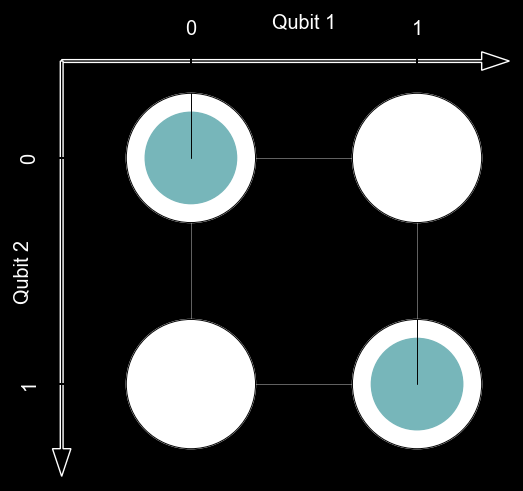

Expectation Value: 1.0


In [2]:
simulator = AerSimulator()

def get_expectation_value(theta_alice, theta_bob, shots=1024):
    """
    Runs the circuit and calculates expectation value E = P(match) - P(mismatch)
    """
    qc = make_chsh_circuit(theta_alice, theta_bob)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()

    # Calculate probabilities
    # keys are '00', '01', '10', '11'
    clicks_match = counts.get('00', 0) + counts.get('11', 0)
    clicks_mismatch = counts.get('01', 0) + counts.get('10', 0)

    E = (clicks_match - clicks_mismatch) / shots
    return E

# Test with aligned bases (Should be highly correlated, E ~ 1.0)
print("Testing Aligned Bases (0, 0):")
print(f"Expectation Value: {get_expectation_value(0, 0)}")

## 6.2. Task: Calculating S

Now it is your turn. We have defined the angles that theory predicts will violate the inequality:

* **Alice A:** $0$
* **Alice a:** $\pi/2$
* **Bob B:** $\pi/4$
* **Bob b:** $-\pi/4$

Write a script below that calculates $E$ for the four required combinations: $(A, B)$, $(A, b)$, $(a, B)$, and $(a, b)$. Then, calculate the final $S$ value.

$$S = E(A, B) + E(A, b) + E(a, B) - E(a, b)$$

In [3]:
# Defined Angles
theta_A = 0
theta_a = np.pi / 2
theta_B = np.pi / 4
theta_b = -np.pi / 4

# TODO: Calculate the 4 expectation values
# Hint: Use the get_expectation_value(alice_angle, bob_angle) function defined above.

E_AB = 0 # TODO
E_Ab = 0 # TODO
E_aB = 0 # TODO
E_ab = 0 # TODO

print(f"E(A, B) = {E_AB}")
print(f"E(A, b) = {E_Ab}")
print(f"E(a, B) = {E_aB}")
print(f"E(a, b) = {E_ab}")

# TODO: Calculate S
S = 0 # TODO

print(f"Final S Value: {S}")

if abs(S) > 2:
    print("VIOLATION: Local Realism is disproven!")
else:
    print("No Violation observed.")

E(A, B) = 0
E(A, b) = 0
E(a, B) = 0
E(a, b) = 0
Final S Value: 0
No Violation observed.


# 6.3. Conclusion and Outlook

In this notebook, we have simulated one of the most profound experiments in the history of physics: **The Bell Test**.

We discovered that the correlations between entangled particles are stronger than any classical theory of "local hidden variables" can explain.
* By calculating the CHSH value $S$, we saw that our quantum system violated the classical limit ($|S| \leq 2$) and approached the quantum limit ($2\sqrt{2} \approx 2.82$).
* This proves that the outcome of a quantum measurement is **truly random** and not determined by pre-existing properties hidden inside the particles.
* Nature, at its fundamental level, is **non-local**: the measurement choice of one observer instantaneously affects the reality of the other, regardless of distance.

### From Philosophy to Technology
While Bell's work started as a way to answer philosophical questions about reality, it has become a cornerstone of modern quantum technology.

In the next notebook, we will implement the **E91 Protocol**, a Quantum Key Distribution (QKD) scheme. E91 uses the violation of Bell's inequality not just to prove Einstein wrong, but to prove that a communication channel is **secure**. If an eavesdropper (Eve) tries to intercept the key, she breaks the entanglement, the Bell inequality is no longer violated, and Alice and Bob instantly know they are being watched.

# References

[1] Bell, J. S. (1964). On the einstein podolsky rosen paradox. Physics Physique Fizika, 1(3), 195.